In [4]:
import pandas as pd
import os

filename = 'df_stage2_biso.pkl'
df_stage2 = pd.read_pickle(filename)
df_stage2[:3]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,100.010,0.0075,0.004330,3.141510e-07,0.010
1,100.020,0.0075,0.004331,6.283020e-07,0.020
2,100.035,0.0075,0.004331,1.099528e-06,0.035


In [5]:
import itertools
import torch
import numpy as np
from sklearn.metrics import mean_squared_error
from core.derivatives.neural import NeuralDerivatives


def find_optimal_nn_params_unsupervised(df, col_name, time_col, 
                                        epochs_grid=[2000, 4000], 
                                        lr_grid=[0.001, 0.005],
                                        hidden_grid=[64, 128],
                                        weights=(1.0, 1.0)):
    """
    Ищет оптимальные параметры нейросети БЕЗ аналитического решения.
    Критерий: Баланс между точностью аппроксимации (MSE функции)
    и гладкостью третьей производной (Roughness d3).
    
    Args:
        weights: (w_mse_func, w_rough_d3)
    """
    
    # Подготовка данных
    df_sorted = df.sort_values(by=time_col)
    t = df_sorted[time_col].values
    y = df_sorted[col_name].values
    
    results = []
    
    # Перебор сетки
    for ep, lr, hd in itertools.product(epochs_grid, lr_grid, hidden_grid):
        print(f"Testing NN: Epochs={ep}, LR={lr}, Hidden={hd}...", end="\r")
        
        # Фиксируем seed для честного сравнения
        torch.manual_seed(42)
        np.random.seed(42)
        
        try:
            nn_deriv = NeuralDerivatives(hidden_dim=hd, lr=lr, epochs=ep, device='cpu')
            nn_deriv.fit(t, y)
            
            # 1. Предсказание самой функции (для оценки точности подгонки)
            y_pred = nn_deriv.predict(t)
            
            # 2. Расчет производных
            d1, d2, d3 = nn_deriv.compute_derivatives(t)
            
            # --- МЕТРИКИ ---
            
            # А. Fidelity (Точность аппроксимации)
            mse_func = mean_squared_error(y, y_pred)
            
            # Б. Roughness (Гладкость рывка - d3)
            # Сумма абсолютных изменений рывка (Total Variation), нормированная на длину
            r3 = np.sum(np.abs(np.diff(d3))) / (len(t) - 1)
            
            results.append({
                'epochs': ep,
                'lr': lr,
                'hidden': hd,
                'mse_func': mse_func,
                'rough_d3': r3
            })
            
        except Exception as e:
            print(f"Error: {e}")

    print("\nSearch complete.")
    res_df = pd.DataFrame(results)
    
    for col in ['mse_func', 'rough_d3']:
        min_v = res_df[col].min()
        max_v = res_df[col].max()
        if max_v > min_v:
            res_df[f'{col}_norm'] = (res_df[col] - min_v) / (max_v - min_v)
        else:
            res_df[f'{col}_norm'] = 0.0
            
    w_mse, w_rough = weights
    
    res_df['score'] = w_mse * res_df['mse_func_norm'] + w_rough * res_df['rough_d3_norm']
    
    best_idx = res_df['score'].idxmin()
    best_params = res_df.loc[best_idx].to_dict()
    
    return best_params, res_df

### Подбор гиперпараметров нейросети (Unsupervised Approach)

Так как аналитическое решение для сжимаемого упруго-пластического материала имеет сложную структуру и отличается от упрощенной кинематической модели, использование аналитики в качестве эталона ("Ground Truth") некорректно.

Мы применяем метод **подбора без учителя**, аналогичный использованному для сплайнов.
Критерием выбора оптимальной архитектуры сети (Learning Rate, Epochs, Hidden Size) служит функционал:

$$ J = w_1 \cdot \text{MSE}(y_{NN}, y_{ANSYS}) + w_2 \cdot \text{Roughness}(\dddot{y}_{NN}) $$

Это позволяет найти сеть, которая:
1.  Максимально точно выучила форму кривой деформации из ANSYS.
2.  При этом не переобучилась на микро-шуме (обеспечивает гладкую 3-ю производную).

d:\Users\complex_deformations\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


Testing NN: Epochs=6000, LR=0.005, Hidden=128...
Search complete.

ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:
Epochs: 6000
LR:     0.001
Hidden: 128
Score:  0.0000


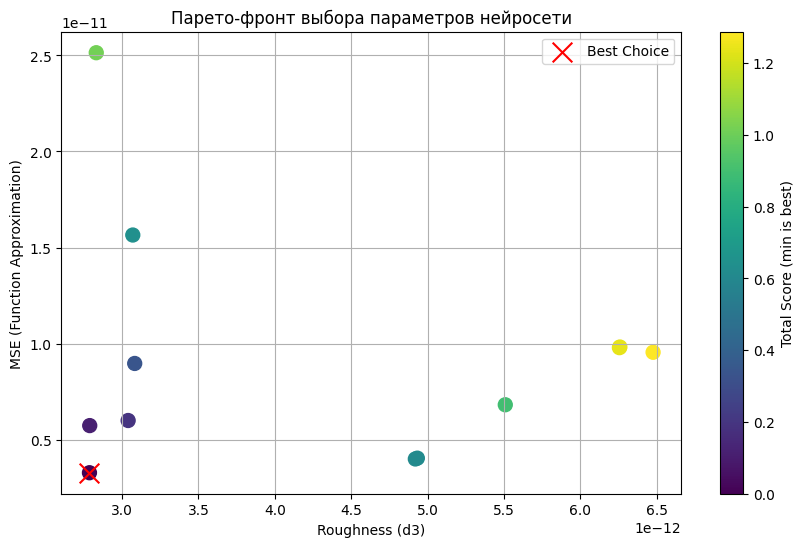

In [6]:
import matplotlib.pyplot as plt


epochs_grid = [2000, 4000, 6000]
lr_grid = [0.001, 0.005] 
hidden_grid = [64, 128]

best_nn_params, res_nn_df = find_optimal_nn_params_unsupervised(
    df_stage2,
    col_name='Eps_3',
    time_col='Time_Local',
    epochs_grid=epochs_grid,
    lr_grid=lr_grid,
    hidden_grid=hidden_grid,
    weights=(1.0, 1.0) # Даем большой вес гладкости рывка
)

print("\nОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:")
print(f"Epochs: {int(best_nn_params['epochs'])}")
print(f"LR:     {best_nn_params['lr']}")
print(f"Hidden: {int(best_nn_params['hidden'])}")
print(f"Score:  {best_nn_params['score']:.4f}")

# Визуализация выбора (Scatter plot)
plt.figure(figsize=(10, 6))
sc = plt.scatter(res_nn_df['rough_d3'], res_nn_df['mse_func'], c=res_nn_df['score'], cmap='viridis', s=100)
plt.colorbar(sc, label='Total Score (min is best)')
plt.xlabel('Roughness (d3)')
plt.ylabel('MSE (Function Approximation)')
plt.title('Парето-фронт выбора параметров нейросети')
plt.grid(True)

# Отметим лучшую точку
best_row = res_nn_df.loc[res_nn_df['score'].idxmin()]
plt.scatter(best_row['rough_d3'], best_row['mse_func'], color='red', marker='x', s=200, label='Best Choice')
plt.legend()
plt.show()

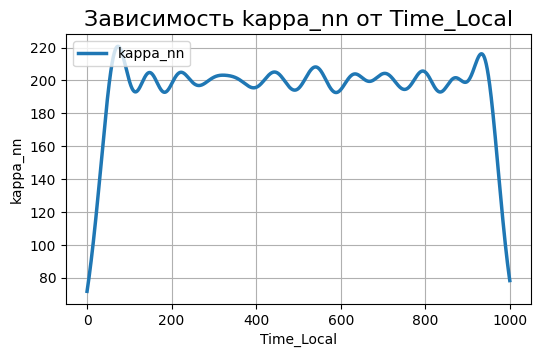

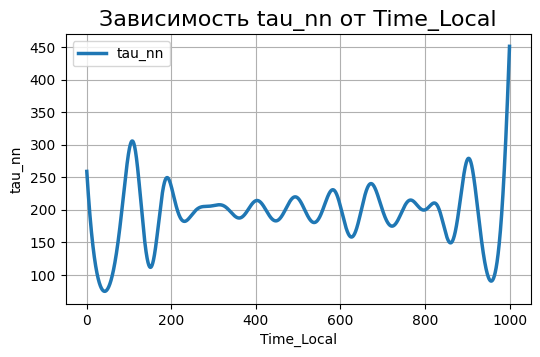

In [7]:
import torch
from core.calculations import calculate_geometry
from core.visualizer import plot_xy

best_epochs = int(best_nn_params['epochs'])
best_lr = best_nn_params['lr']
best_hidden = int(best_nn_params['hidden'])

components = ['Eps_1', 'Eps_2', 'Eps_3']

for col in components:
    torch.manual_seed(42)
    nn_model = NeuralDerivatives(
        hidden_dim=best_hidden, lr=best_lr, epochs=best_epochs, device='cpu'
    )
    
    t_vals = df_stage2['Time_Local'].values
    y_vals = df_stage2[col].values
    
    nn_model.fit(t_vals, y_vals)
    d1, d2, d3 = nn_model.compute_derivatives(t_vals)
    
    df_stage2[f'd{col}_nn'] = d1
    df_stage2[f'd2{col}_nn'] = d2
    df_stage2[f'd3{col}_nn'] = d3

# Расчет геометрии
s_nn, k_nn, t_nn = calculate_geometry(df_stage2, suffix='_nn')
df_stage2['kappa_nn'] = k_nn
df_stage2['tau_nn'] = np.abs(t_nn)

# Сравнение Кручения
plot_xy(
    data_pairs=[("BISO", df_stage2)],
    x_col="Time_Local",
    y_cols=["kappa_nn"],
)
plot_xy(
    data_pairs=[("BISO", df_stage2)],
    x_col="Time_Local",
    y_cols=["tau_nn"],
)